# Looking into the CLS token dynamics in the classifier

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.core.pylabtools import figsize

import seaborn as sns

import numpy as np
import pandas as pd

from tqdm import tqdm

import torch

import sys
sys.path.append('..')

from src.models.TTA_model import ClassifierWithTTA
from src.data.activity_data import ActivityGradientDataDict
from src.data.image_data import balanced_train_subsets

W1231 16:15:00.136000 26489 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


## Starting from where we left off in 1.2

We saw that, randomizing the CLS tokens in different layers, we find that the CLS tokens contain no CLS specific information. This leads to two immediate directions:

1. What happens if we make the classifier read-out less powerful? Where in the network does the CLS token representation start to arise?
2. Can we completely isolate the CLS token into the classification layers?


In [2]:
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')

def model_accuracy(model, dataset):
    dl = torch.utils.data.DataLoader(dataset, batch_size=32)
    outputs = []
    
    for batch in tqdm(iter(dl)):
        images, labels = batch
        preds = model.forward(images.to('mps')).logits.argmax(1).cpu()
    
        outputs.append(preds.cpu() == labels)

    return torch.concat(outputs)

def randomize_layer_cls_token(model, layer_name, layer_ind, dataset, debug=False):
    def randomization_hook(module, input, output):
        if debug:
            print('in hook')
        copied_output = output.clone()
        batch, tokens, dims = copied_output.shape
        
        #ind_perm = torch.randperm(batch)
        copied_output[:, 0, :] = torch.randn(batch, dims)
        #copied_output[ind_perm, 0, :]
        
        return copied_output


    layer_registry = {'embedding': model.embedding.vit.encoder.layer,
                      'classifier': model.classifier.vit.encoder.layer
                     }        

    handle = layer_registry[layer_name][layer_ind].register_forward_hook(randomization_hook)
    outputs = model_accuracy(model, dataset)

    handle.remove()
    return outputs
    

/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


#### Previous results:

In [3]:
base_ckpt = '../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best'
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')
results = []

# baseline
cls_model = ClassifierWithTTA.from_pretrained(base_ckpt)
cls_model = cls_model.to('mps')
cls_model = cls_model.eval()

baseline = model_accuracy(cls_model, image_data).float().mean()
results.append({'layer': f'Baseline', 'accuracy': baseline.item()})

for layer_name, layer_num in [('embedding', 0), ('embedding', 11), ('classifier', 0), ('classifier', 1)]:
    cls_model = ClassifierWithTTA.from_pretrained(base_ckpt)
    cls_model = cls_model.to('mps')
    cls_model = cls_model.eval()
    
    accuracy = randomize_layer_cls_token(cls_model, layer_name, layer_num, image_data, debug=False).float().mean()

    results.append({'layer': f'{layer_name}_{layer_num}', 'accuracy': accuracy.item()})


results = pd.DataFrame(results)

Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:01<00:00,  5.10it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:00<00:00,  5.17it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:01<00:00,  5.12it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:29<00:00,  3.50it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:14<00:00,  4.18it/s]


Text(0.5, 1.0, 'Accuracy after randomizing CLS tokens in a layer')

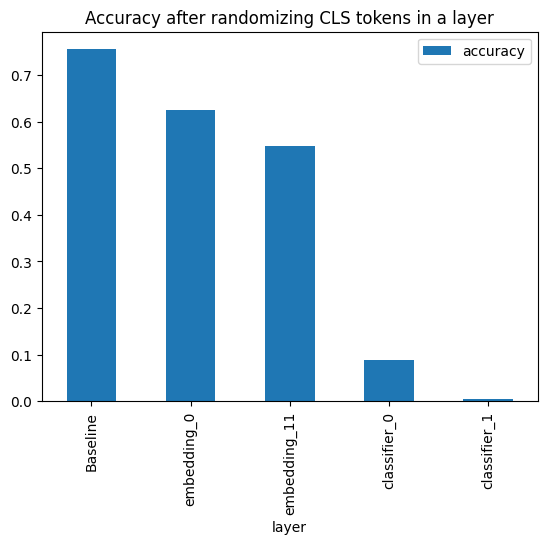

In [4]:
results.plot.bar(x='layer', y='accuracy')
plt.title('Accuracy after randomizing CLS tokens in a layer')

This is identical to before. There _is_ some loss in the early layers, but the embedding 0 vs embedding 11 is much less than I would have expected.

I think that this degree of loss is consistent with 'the network wasn't trained for this'

### 'Pushing down' CLS token information:

I trained a model with a linear-only decoder. How does the CLS token causal effect look now?

In [5]:
embed_only_ckpt = '../experiments_base/2025-12-24(00:42:34)-no_classifier_transformer/checkpoints/full/best'

results_embed = []
layer_name  ='embedding'

# baseline
cls_model = ClassifierWithTTA.from_pretrained(embed_only_ckpt)
cls_model = cls_model.to('mps')
cls_model = cls_model.eval()

baseline = model_accuracy(cls_model, image_data).float().mean()
results_embed.append({'layer': f'Baseline', 'accuracy': baseline.item()})

for layer_num in range(12):
    cls_model = ClassifierWithTTA.from_pretrained(embed_only_ckpt)
    cls_model = cls_model.to('mps')
    cls_model = cls_model.eval()
    
    accuracy = randomize_layer_cls_token(cls_model, layer_name, layer_num, image_data, debug=False).float().mean()

    results_embed.append({'layer': f'{layer_name}_{layer_num}', 'accuracy': accuracy.item()})


results_embed = pd.DataFrame(results_embed)

Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:03<00:00,  4.93it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:02<00:00,  5.00it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:01<00:00,  5.05it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:02<00:00,  4.99it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:03<00:00,  4.96it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:03<00:00,  4.90it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:04<00:00,  4.87it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:03<00:00,  4.90it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:03<00:00,  4.89it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:04<00:00,  4.87it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:05<00:00,  4.81it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:05<00:00,  4.77it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:05<00:00,  4.74it/s]


Text(0.5, 1.0, 'Accuracy after randomizing CLS tokens in a layer')

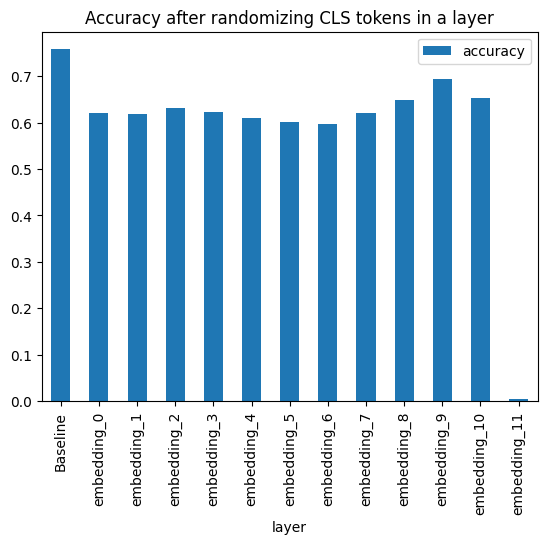

In [6]:
results_embed.plot.bar(x='layer', y='accuracy')
plt.title('Accuracy after randomizing CLS tokens in a layer')

#### Huh. This is an odd result. 


1. The major accuracy destruction does not appear until the very last layer of the embedding.
2. There is a small but substantial impact ~12% (same as observed previously) of randomization in the very earliest layers.
3. Accuracy slowly decreases toward layer 6 before _increasing_ toward layer 9. Approximately an 8% increase.
   - pattern holds across replicates.

Leads to several questions:
1. What accounts for the early difference in performance from baseline?
    - lack of position encoding?
    - slightly earlier randomization than in the randomized model?
2. What accounts for the strange _increase_ midway through? Is this the point at which the CLS token -> image token information flow is 'complete'?
   - Is this where the effect of position embedding 'wears off'?
3. How is the accuracy still so good with only 1 embedding layer?
    - Seems to imply that the idea to 'push down' the CLS token dependence does not work.
    - The network prioritizes learning image token representations that are able to 'strongly separate' different classes in the final layer. Not on learning to slowly transform the image representation.


### The CLS token has little influence on outputs. Did it play a role earlier in the network?

Can we just use the lower half of the network in embedding mode, without any CLS tokens, and introduce the CLS tokens later in the classifier.

In [2]:
base_ckpt = '../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best'
cls_model = ClassifierWithTTA.from_pretrained(base_ckpt)
cls_model = cls_model.to('mps')
cls_model = cls_model.eval()

Loading weights from local directory


In [3]:
def alt_forward(model, pixel_values, mode='alt_prepend'):
    """ Alternative model forward that does not use the CLS token until the classifier
    use_alt: turns on and off the alternative encoding path 
    """
    pixel_values = model.preprocess(pixel_values)

    if mode == 'alt_prepend':
        x = model.embedding.forward(pixel_values).logits

        # Only now we add the cls tokens.
        batch, n_tokens, n_dim = x.shape
        assert n_tokens == 196
    
        cls_tokens = torch.randn(batch, 1, n_dim, device=x.device)
        x = torch.concat([cls_tokens, x], dim=1)

    elif mode == 'alt_postpend':
        x = model.embedding.forward(pixel_values).logits

        # Only now we add the cls tokens.
        batch, n_tokens, n_dim = x.shape
        assert n_tokens == 196
    
        cls_tokens = torch.randn(batch, 1, n_dim, device=x.device)
        x = torch.concat([x, cls_tokens], dim=1)


    elif mode == 'base':
        x = model.embedding.embedding(pixel_values)

    elif mode == 'base_random':
        x = model.embedding.embedding(pixel_values)
        batch, tokens, dim = x.shape
        x[:, 0, :] = torch.randn(batch, dim)
        
    x = model.classifier.vit.encoder(x).last_hidden_state
    x = model.classifier.vit.layernorm(x)[:, 0, :]
    logits = model.classifier.classifier(x)

    return logits



In [11]:
dl = torch.utils.data.DataLoader(image_data, batch_size=32)
outs = {'base':[],
        'base_random': [],
        'alt_prepend': [],
       }


for batch in tqdm(iter(dl)):
    images, labels = batch

    for mode in outs.keys():
        preds = alt_forward(cls_model, images.to('mps'), mode)
        outs[mode].append( (preds.argmax(1).cpu() == labels))



100%|█████████████████████████████████████████| 313/313 [03:43<00:00,  1.40it/s]


Text(0.5, 1.0, 'Using embedding model with no CLS tokens.')

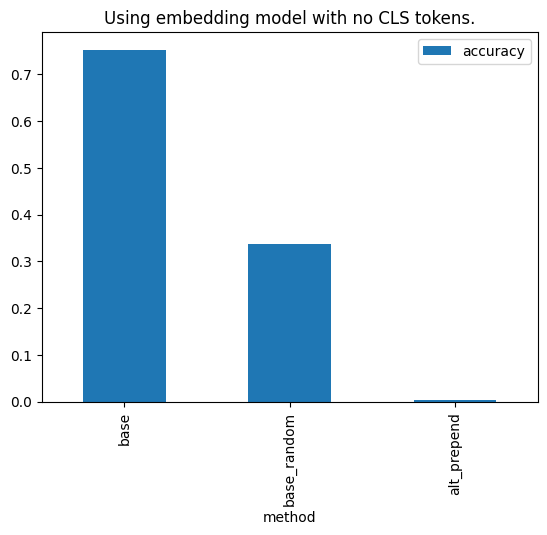

In [16]:
results_embed_mode = [{'method': key, 'accuracy': torch.concat(value).float().mean().item()} for key, value in outs.items()]
results_embed_mode = pd.DataFrame(results_embed_mode)
results_embed_mode.plot.bar(x='method', y='accuracy')
plt.title('Using embedding model with no CLS tokens.')

`base` is a negative control on the code. `alt_prepend` is experimental. `base_random` was supposed to be another negative control.

1. I'm surprised to see this much effect in the `base_random` case. However, I don't think this is a sign of a bug in the code: `base_random` randomizes at the step between the embedding and classifier, an produces outputs that are midway between randomizing each of these.

2. The prepend result (in compairison to the base random result) is a strong rejection of the idea that introducing tokens at this point is equivalent to randomizing the cls tokens at the same point.

I suspect that this is because:
- _the network wasn't trained for this_
- base mode puts the CLS token at the 0 index in the sequence, and the image and (1, n+1), while this mode does image processing in the (0, n) positions

This addition to the loss seen in `base_random` from token randomization.

#### There's a pattern here

The _last layer_ of the embedding seems to be responsible for mapping the CLS token to the 'decoding space'


### Another check:

This base randomization result seems at odds with our previous results in notebook 1.2 swapping cls tokens and activity, and finding that outputs depend almost entirely on the activity.

__Answer:__ Everything replicates properly.

In [2]:
from src.models.TTA_model import ClassifierWithTTA
from src.data.image_data import balanced_train_subsets
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')
activity_data_test = torch.load('../activity_analysis/2025-12-22_01_44_59_data_gen/activity_data_test.pt')
print((activity_data_test['gts'] == image_data[:][1]).all())

model_cls = ClassifierWithTTA.from_pretrained('../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best')
model_cls = model_cls.to('mps')
model_cls = model_cls.eval()

/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


tensor(True)
Loading weights from local directory


#### What is the hook actually measuring?

The previous activity used hooks to record. Is this the same as the model outputs?

Ans: yes.

In [3]:
all_tokens = []
def recording_hook(module, input, output):
    all_tokens.append(output.detach().clone().cpu())

handle = model_cls.embedding.vit.layernorm.register_forward_hook(recording_hook)

In [4]:
processed = model_cls.preprocess(image_data[2:4][0].to('mps'))
activity = model_cls.embedding.embedding(processed)

In [5]:
(activity.cpu() == all_tokens[0]).all()

tensor(True)

#### Repeating the cls vs image token experiment

Slightly rewritten

In [6]:
def decode_token(token, model, base_activity):
    x = base_activity.clone()
    x[0,0,:] = token.to('mps')
    
    x = model.classifier.vit.encoder(x).last_hidden_state
    x = model.classifier.vit.layernorm(x)[:, 0, :]
    logits = model.classifier.classifier(x)
    return logits.argmax(1)

def sample_pairs(model, image_data, activity_data, linked=False, normal_tokens=False):
    results = {}
    i = torch.randint(10000, (1,))[0]
    if linked:
        j = i
    else:
        j = torch.randint(10000, (1,))[0]

    results['image_gt'] = image_data[i:i+1][1].item()
    image = image_data[i:i+1][0]

    processed = model.preprocess(image.to('mps'))
    embedding = model.embedding.embedding(processed)

    results['cls_token_gt'] = activity_data['gts'][j].item()
    cls_token = activity_data['activity'][j][torch.randint(50, (1,))]

    if normal_tokens:
        cls_token = torch.randn(1,1, embedding.shape[2])

    results['joint_output'] = decode_token(cls_token, model, embedding).item()

    return results

In [4]:
linked_results = []
for i in tqdm(range(5000)):
    linked_results.append(sample_pairs(model_cls, image_data, activity_data_test, linked=True))

linked_results = pd.DataFrame(linked_results)

100%|███████████████████████████████████████| 5000/5000 [01:00<00:00, 83.06it/s]


In [5]:
random_results = []
for i in tqdm(range(10000)):
    random_results.append(sample_pairs(model_cls, image_data, activity_data_test, linked=False))

random_results = pd.DataFrame(random_results)

100%|█████████████████████████████████████| 10000/10000 [02:00<00:00, 82.75it/s]


Checks:

In [6]:
(linked_results['cls_token_gt'] == linked_results['image_gt']).all()

np.True_

In [7]:
(linked_results['image_gt'] == linked_results['joint_output']).mean()

np.float64(0.7512)

Linked control: gts are aligned, 75% output accuracy

In [8]:
(random_results['cls_token_gt'] == random_results['image_gt']).mean()

np.float64(0.0052)

In [9]:
(random_results['cls_token_gt'] == random_results['joint_output']).mean()

np.float64(0.009)

In [10]:
(random_results['image_gt'] == random_results['joint_output']).mean()

np.float64(0.733)

The reproduces the result in 1.2: Almost all of the output is determined by the image tokens, rather than the cls token. Important control: the cls and image tokens are almost never from the same underlying class.

What if we compare to normal cls tokens again?

In [11]:
normal_results = []
for i in tqdm(range(5000)):
    normal_results.append(sample_pairs(model_cls, image_data, activity_data_test, linked=False, 
                                      normal_tokens=True))

normal_results = pd.DataFrame(normal_results)

100%|███████████████████████████████████████| 5000/5000 [01:00<00:00, 82.03it/s]


In [12]:
(normal_results['image_gt'] == normal_results['joint_output']).mean()

np.float64(0.3434)

Yes. Reproduces the result that I saw above.



#### Conclusion:

Everything replicates. Outputs _are_ dominated by image token identity. Sampling from a normal distribution of cls tokens _does_ send the accuracy to 30%

### Interpreting this:

The results above:
- outputs are dominated by image token identity
- normal distribution of cls tokens sends the accuracy to 30%
- sampling instead from the recorded cls_token activity distribution gives 73% accuracy, almost as good as the paired.

This looks to me like _exactly_ what I thought I would see in Notebook 1.3, but specific to the classifier: there is a specific distribution of tokens that works well as inputs to the classifier (I can probably get back up to 75% by training with this sampling scheme). Deviating from this kills classifier performance.

This, then re-raises the question of the fixed-point distribution, at the scale of the classifier. Note that this is _conditional_ on the encoder.

This is saying exactly the thing that we're looking for: the classifier's performance is contingent on the _distribution_ of cls tokens, but not on the individual cls tokens. In other words, that distribution can be used to test classifier performance. (HOWEVER, individual datapoint distributions will not be the same as multi-point distributions, so that adds a wrinkle)


## How does shuffled activity compare to randomized?

These measurements test the balance of two factors:
1. How much information is in the cls_token?
2. How much does the over-all location of tokens matter?

(shuffle acc > normal acc) =>  the location is important, but not the value

(normal acc > shuffle acc) =>  the value more important than the location

I expect that shuffle will generally outperform normal resampling because the tokens are 'about right'. If the reverse occurs, this is a sign that information in the CLS token is _being used_ heavily. However, this is not a very sensitive metric, because the normal resampling is a very blunt intervention.

### Shuffled activity in the base model

In [25]:
from src.analysis.layer_randomization import randomize_cls_token
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')

/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


#### Model with transformer classifier

In [3]:
# baseline
base_ckpt = '../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best'
readout_model = ClassifierWithTTA.from_pretrained(base_ckpt)
readout_model = readout_model.to('mps')
readout_model = readout_model.eval()

embedding_layers = 'embedding.vit.encoder.layer.{i}'
classifier_layers = 'classifier.vit.encoder.layer.{i}'

Loading weights from local directory


In [4]:
readout_accuracy = []
for embedding_ind in range(12):
    layer_name = embedding_layers.format(i=embedding_ind)

    for randomization_mode in ['normal', 'shuffle']:
        acc = randomize_cls_token(readout_model, layer_name, image_data, randomization_mode=randomization_mode)
        readout_accuracy.append({'module': 'embedding', 'layer': embedding_ind, 'accuracy': acc,
                        'randomization': randomization_mode
                       })

for classification_ind in range(2):
    layer_name = classifier_layers.format(i=classification_ind)

    for randomization_mode in ['normal', 'shuffle']:
        acc = randomize_cls_token(readout_model, layer_name, image_data, randomization_mode=randomization_mode)
        readout_accuracy.append({'module': 'classifier', 'layer': classification_ind, 'accuracy': acc,
                        'randomization': randomization_mode
                       })


readout_accuracy = pd.DataFrame(readout_accuracy)

100%|███████████████████████████████████████████| 79/79 [01:05<00:00,  1.20it/s]


In [6]:
readout_accuracy['layer_name'] = readout_accuracy['module'] + readout_accuracy['layer'].astype(str)

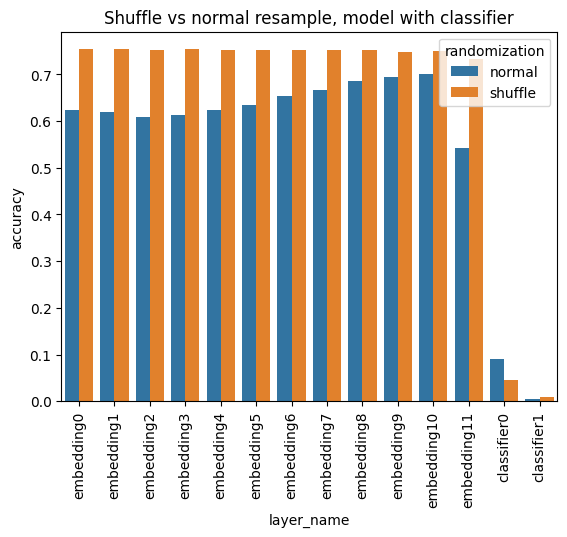

In [16]:
sns.barplot(readout_accuracy, x='layer_name', y='accuracy', hue='randomization')
_=plt.xticks( rotation=90)
_=plt.title('Shuffle vs normal resample, model with classifier')

Notes:
1. Shuffle accuracy is close to baseline throughout the embedding. Slight decrease at layer 11.
2. Shuffle accuracy collapses in the classifier. The first classifier layer shows evidence for class-specific information: more effect than 'pure' randomization.
3. Fulctuating normal distribution accuracy through the network: must relate to how 'similar' the cls tokens at these points are to normal samples
    - this is similar to the effect that we saw in the pure embedding network (above and below)
    - it again increases toward layer 10, before falling suddenly at layer 11.


#### Double check behavior of embedding outputs

In [27]:
layer_name = 'embedding.vit.layernorm'
check = []
for randomization_mode in ['normal', 'shuffle']:
    acc = randomize_cls_token(readout_model, layer_name, image_data, randomization_mode=randomization_mode)
    check.append({'module': 'embedding', 'layer': embedding_ind, 'accuracy': acc,
                    'randomization': randomization_mode
                   })

check = pd.DataFrame(check)

100%|███████████████████████████████████████████| 79/79 [00:57<00:00,  1.37it/s]


<Axes: xlabel='randomization', ylabel='accuracy'>

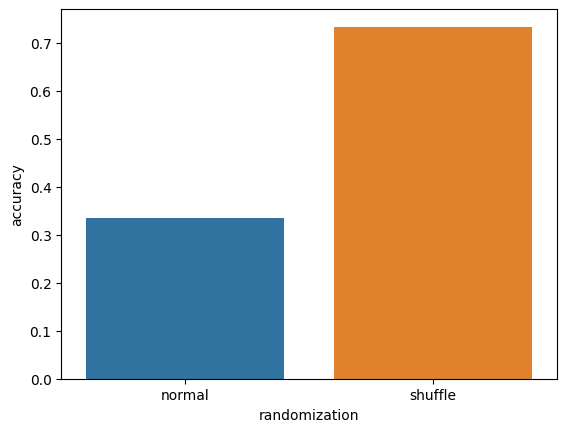

In [29]:
sns.barplot(check, x='randomization', y='accuracy', hue='randomization')

Slightly lower shuffle outputs, as with the last transformer layer of the embedding. Significantly lower normal distribution outputs, probably a simple result of missing layer norm.

#### Model with only embedding

In [17]:
# baseline
embed_only_ckpt = '../experiments_base/2025-12-24(00:42:34)-no_classifier_transformer/checkpoints/full/best'

embed_only_model = ClassifierWithTTA.from_pretrained(embed_only_ckpt)
embed_only_model = embed_only_model.to('mps')
embed_only_model = embed_only_model.eval()

embedding_layers = 'embedding.vit.encoder.layer.{i}'

embed_only_accuracy = []
for embedding_ind in range(12):
    layer_name = embedding_layers.format(i=embedding_ind)

    for randomization_mode in ['normal', 'shuffle']:
        acc = randomize_cls_token(embed_only_model, layer_name, image_data, randomization_mode=randomization_mode)
        embed_only_accuracy.append({'module': 'embedding', 'layer': embedding_ind, 'accuracy': acc,
                        'randomization': randomization_mode
                       })

embed_only_accuracy = pd.DataFrame(embed_only_accuracy)

Loading weights from local directory


100%|███████████████████████████████████████████| 79/79 [00:55<00:00,  1.43it/s]


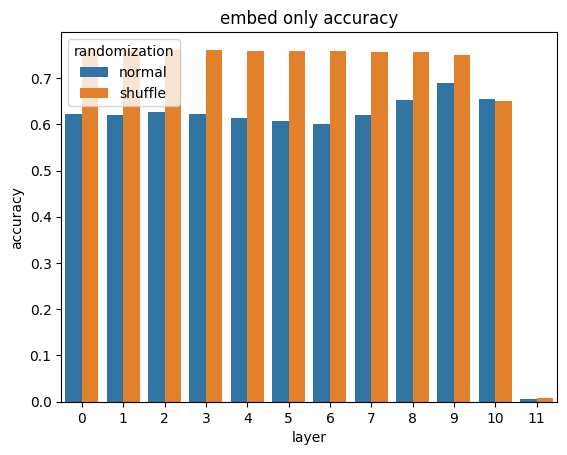

In [18]:
sns.barplot(embed_only_accuracy, x='layer', y='accuracy', hue='randomization')
_=plt.title('embed only accuracy')

A couple of things worth noting:
1. Shuffle accuracy matches baseline across the lower layers
   - there is a (moderate) impact of having the wrong token distribution here.
2. Shuffle accuracy is decreasing: no increase toward the end of the embedding
    - the increase when randomizing by normal sampling is likely due to some similarity between the gt embedding at that point and the normal distribution samples.
3. The shuffled embedding _does_ see a small decrease in layer 10.
    - this is the only point where normal sampling is (marginally) better than shuffled.
4. Final fall-off at layer 11: back to random performance.
    - in some ways, this is a control on the results: the shuffling does matter somewhere

#### Indeed, shuffling has almost no impact on the output distribution until the last stages of the network.

### Does randomizing CLS tokens help with corrupted data?


In [42]:
corrupted_acc = pd.read_csv('../results_data/corrupted_accuracy_with_randomization_token_sampling.csv')
corrupted_acc = corrupted_acc.rename(columns={'randomize': 'cls_token_sample'})
corrupted_acc = corrupted_acc.drop(columns='Unnamed: 0')

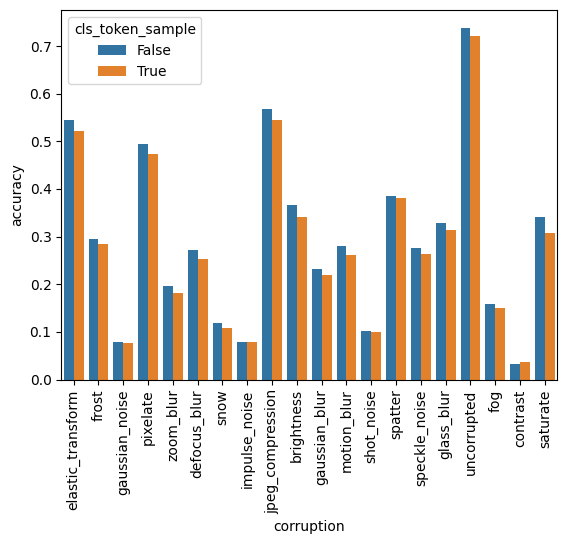

In [43]:
sns.barplot(corrupted_acc, x='corruption', y='accuracy', hue='cls_token_sample')
_=plt.xticks( rotation=90)

Answer: No. CLS token resampling has a small but consistent impact: decreasing model accuracy.

In [44]:
previous_accuracy = pd.read_csv('../results_data/accuracy_full.csv', index_col=False)
previous_accuracy = previous_accuracy.drop(columns='Unnamed: 0')

In [45]:
previous_accuracy['randomized'] = False
corrupted_acc['randomized'] = True

In [46]:
deterministic_results = previous_accuracy[previous_accuracy['model_layers'] == 2].drop(columns='model_layers')
deterministic_results = deterministic_results.fillna('uncorrupted')

In [47]:
randomized_results = corrupted_acc[ corrupted_acc['cls_token_sample'] == False].drop(columns='cls_token_sample')

In [48]:
randomization_comparision = pd.concat([deterministic_results, randomized_results])

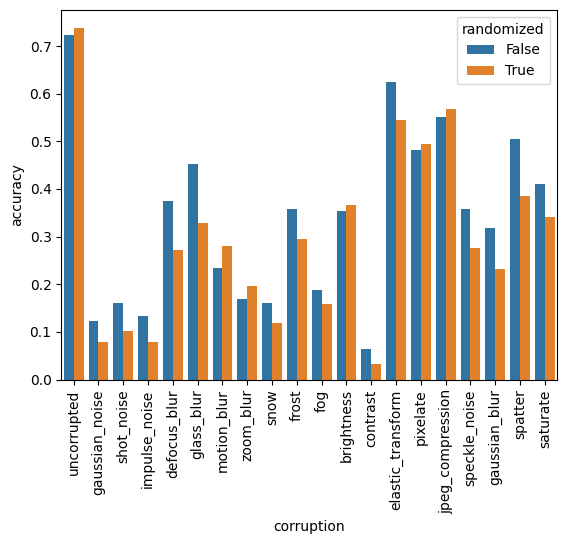

In [49]:
sns.barplot(randomization_comparision, x='corruption', y='accuracy', hue='randomized')
_=plt.xticks( rotation=90)

Moreover, using random cls tokens in the model at all, is almost universally _bad_ for generalization. (excepting a couple of rare cases).

(However, the general similarity here wrt different corruptions does validate use this case as a control above.)

#### Conclusion:

1. Introducing randomness into the CLS tokens did not improve robustness of the model, but instead hurt it.
2. More-over, resampling CLS tokens from the baseline distribution also did not help. It universally hurt performance.

The arguments that we have now disproved:
1. training with randomness helps the network handle structured changes in the inputs
2. loss of model performance is _caused_ by a CLS token distribution that deviates from what the classifier expects.

The second result is unsurprising: it was a hail-mary anyway. The first result is a bit more troubling: it means that initial CLS token resampling is _not_ acting as a regularizer on the generalization. Instead, it appears to cause more over-fitting. Would need to rerun side-by-side with the same hyper-parameters (eg. dropout) to be sure.


## Activity analysis on classifier activity:

This is similar to the analysis in 1.2, but using a layer where we know that there is signal about the class identity.

In [2]:
val_ds = torch.load('../activity_analysis/2025-12-29_00_11_56_data_gen/activity_classifier_val.pt')
test_ds = torch.load('../activity_analysis/2025-12-29_02_03_57_data_gen/activity_classifier_test.pt')

In [3]:
def correctness_num_outputs_analysis(ds):
    is_correct = ds['predictions'].mode(dim=1).values == ds['gts']
    num_decoded = list(map(lambda row:len(row.unique()), ds['predictions']))

    return pd.DataFrame({'correct': is_correct, 'num_outputs': num_decoded})

    
val_analysis = correctness_num_outputs_analysis(val_ds)
test_analysis = correctness_num_outputs_analysis(test_ds)


#### Correct vs output counts

Text(0.5, 1.0, 'Test')

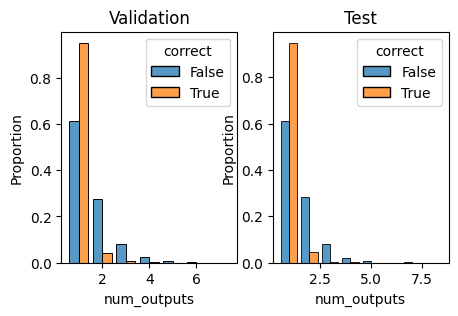

In [4]:
figsize(5,3)
plt.subplots(1,2)
plt.subplot(1,2,1)
sns.histplot(val_analysis, discrete=True, x='num_outputs', hue='correct',
            multiple='dodge', stat='proportion', common_norm=False,
            shrink=0.8 
            )
plt.title('Validation')

plt.subplot(1,2,2)
sns.histplot(test_analysis, discrete=True, x='num_outputs', hue='correct',
            multiple='dodge', stat='proportion', common_norm=False,
            shrink=0.8 
            )
plt.title('Test')

### Exploration:

In [4]:
cov_tr_val = [torch.trace(row.T.cov()).item() for row in val_ds['activity']]
cov_tr_test = [torch.trace(row.T.cov()).item() for row in test_ds['activity']]

val_analysis['cov_tr'] = cov_tr_val 
test_analysis['cov_tr'] = cov_tr_test

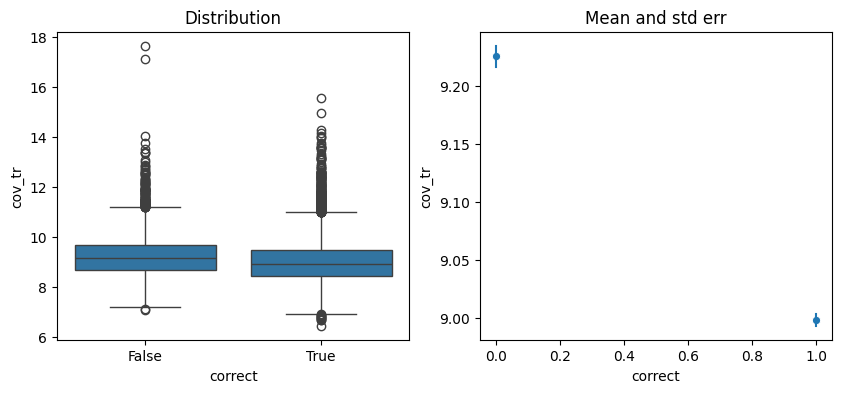

In [5]:
figsize(10,4)
plt.subplots(1,2)
plt.subplot(1,2,1)
plt.title('Distribution')
sns.boxplot(val_analysis, x='correct', y='cov_tr')

plt.subplot(1,2,2)
plt.title('Mean and std err')
_=sns.lineplot(val_analysis, x='correct', y='cov_tr', marker='o', linestyle='',
            err_style='bars', errorbar='se')

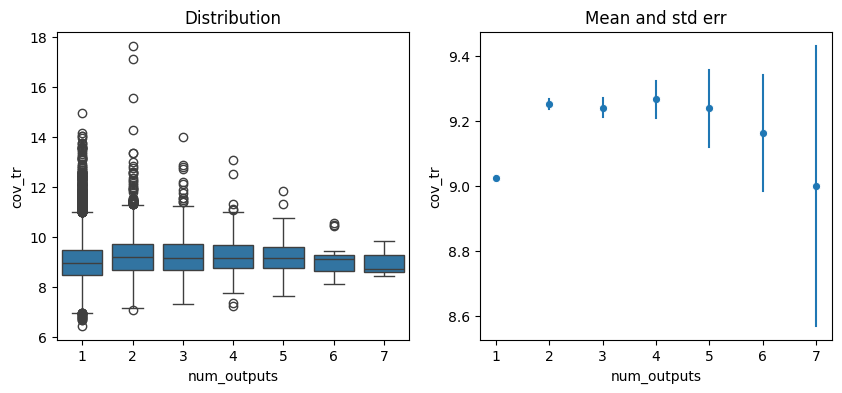

In [6]:
figsize(10,4)
plt.subplots(1,2)
plt.subplot(1,2,1)
plt.title('Distribution')
sns.boxplot(val_analysis, x='num_outputs', y='cov_tr')

plt.subplot(1,2,2)
plt.title('Mean and std err')
_=sns.lineplot(val_analysis, x='num_outputs', y='cov_tr', marker='o', linestyle='',
             err_style='bars', errorbar='se')



The distributions overlap heavily. However, there are strong differences on average: bigger covarince trace in incorrect activity and multiple decodings

In [7]:
from sklearn.decomposition import PCA

In [8]:
def pcaev(row): 
    pca = PCA(n_components=20)
    pca = pca.fit(row)
    return pca.explained_variance_

In [9]:
explained_variance = np.array(list(map(pcaev, val_ds['activity'])))

In [10]:
explained_variance.shape

(30000, 20)

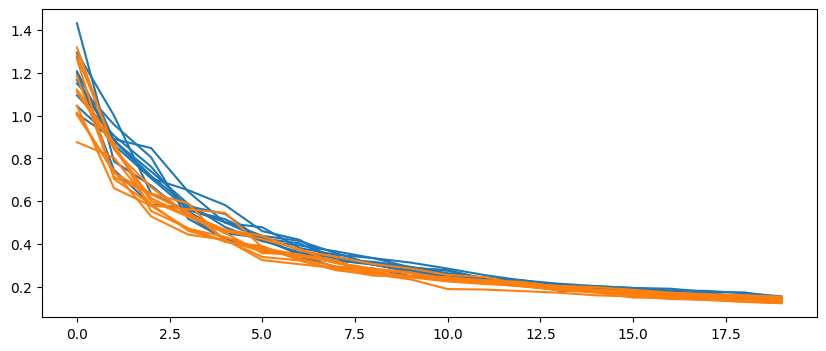

In [11]:
_=plt.plot(explained_variance[val_analysis['correct']][0:10].T, c='C0')
_=plt.plot(explained_variance[~val_analysis['correct']][0:10].T, c='C1')

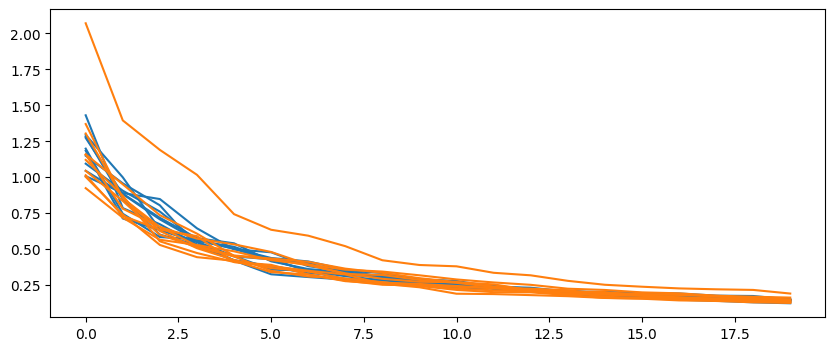

In [12]:
_=plt.plot(explained_variance[val_analysis['num_outputs'] <= 1][0:10].T, c='C0')
_=plt.plot(explained_variance[val_analysis['num_outputs'] > 1][0:10].T, c='C1')

Perhaps the explained-variance falls off faster for incorrect answers...

#### How good can we make an xgboost model?

- Still see 100% validation accuracy with deepsets foundation model after epoch 1.
- Subtracting the mean reduces this to a more slowly rising validation accuracy (although it still ends up very good)

Using that second one here.

In what follows I flip the meaining of 0 and 1, so 1 = mistake.

__Ans:__ Not good at all. No better than before, even though the feature extractor is behaving slightly better.

In [13]:
from src.models.activity_analysis import DeepSetsFoundation
from sklearn.metrics import roc_curve, precision_recall_curve, \
                            average_precision_score, roc_auc_score

def mean_subtract_and_label_flip(data_dict):
    activity = data_dict['activity']
    correct_outs = 1. - (data_dict['predictions'].mode(1).values == data_dict['gts']).to(torch.float)

    activity = activity - activity.mean(1)[:, None, :].expand(activity.shape)
    return activity, correct_outs


def mean_subtract_and_non_unique(data_dict):
    activity = data_dict['activity']
    counts = torch.tensor([ len(row.unique()) for row in data_dict['predictions']])
    non_unique = (counts >1).float()

    activity = activity - activity.mean(1)[:, None, :].expand(activity.shape)
    return activity, non_unique


embedding_model = DeepSetsFoundation.load_from_checkpoint('../activity_analysis/2025-12-30_13_58_39_train/epoch=8-step=2565.ckpt')
embedding_model = embedding_model.to('mps')
embedding_model = embedding_model.eval()

def map_embed(activity):
    dl = torch.utils.data.DataLoader(activity, shuffle=False, batch_size=128)
    results = []
    for batch in tqdm(iter(dl)):
        results.append(embedding_model(batch.to('mps')).detach().cpu())

    return torch.concat(results)

def model_performance(model, test_features, test_labels):
    print(test_features.shape)
    print(model.predict(test_features).shape)
    accuracies = {'overall': (model.predict(test_features) == test_labels).float().mean(),
                  'gt = error': (final_model.predict(test_features) == test_labels)[test_labels==1].float().mean(),
                  'gt = correct': (final_model.predict(test_features) == test_labels)[test_labels==0].float().mean()
                 }

    y_pred_proba = final_model.predict_proba(test_features)[:, 1]

    figsize(12, 4)
    plt.subplots(1,3)
    plt.subplot(1,3,1)
    plt.title('Accuracy')
    plt.bar(accuracies.keys(), accuracies.values())

    plt.subplot(1,3,2)
    plt.title('ROC')    
    fpr, tpr, thresholds = roc_curve(test_labels, y_pred_proba)
    roc_auc = roc_auc_score(test_labels, y_pred_proba)
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.xlabel('fpr')
    plt.ylabel('tpr')
    plt.legend()

    plt.subplot(1,3,3)
    plt.title('PRC')    
    precision, recall, thresholds = precision_recall_curve(test_labels, y_pred_proba)
    prscore = average_precision_score(test_labels, y_pred_proba)
    plt.plot(recall, precision, color='blue', label=f'PR curve (AUC = {prscore:.2f})')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.xlabel('recall')
    plt.ylabel('precision')
    plt.legend()
    

In [14]:
from sklearn.decomposition import PCA

train_activity, train_labels = mean_subtract_and_label_flip(val_ds)
pca = PCA(n_components=10).fit(train_activity.mean(1))

train_means = torch.tensor(pca.transform(train_activity.mean(1)))
train_embedding = map_embed(train_activity)

train_features = torch.concat([train_embedding, train_means], dim=1)

100%|████████████████████████████████████████| 235/235 [00:01<00:00, 125.17it/s]


In [15]:
test_activity, test_labels = mean_subtract_and_label_flip(test_ds)

test_means = torch.tensor(pca.transform(test_activity.mean(1)))
test_embedding = map_embed(test_activity)

test_features = torch.concat([test_embedding, test_means], dim=1)

100%|██████████████████████████████████████████| 79/79 [00:00<00:00, 132.53it/s]


In [16]:
import optuna
import xgboost as xgb

train_data = xgb.DMatrix(train_features, label=train_labels)

def cv_performance(trial):
    params = {
        'objective': 'binary:logistic',
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.15, 6) ,
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    cv_results = xgb.cv(
                        params,
                        train_data,
                        num_boost_round=100,
                        early_stopping_rounds=20,
                        nfold=5,
                        metrics='aucpr',
                        stratified=True,
                        as_pandas=True,
                    )

    return cv_results['test-aucpr-mean'].max()


study = optuna.create_study(direction='maximize')
study.optimize(cv_performance, n_trials=50)

[I 2025-12-31 13:20:59,675] A new study created in memory with name: no-name-b1d19b05-18ba-4565-8cf5-d81531702c94
[I 2025-12-31 13:21:05,385] Trial 0 finished with value: 0.4178501043150802 and parameters: {'scale_pos_weight': 3.4296832974097753, 'max_depth': 8, 'min_child_weight': 7, 'learning_rate': 0.04026008295201512, 'subsample': 0.6135812727304484, 'colsample_bytree': 0.6665973278012818}. Best is trial 0 with value: 0.4178501043150802.
[I 2025-12-31 13:21:09,530] Trial 1 finished with value: 0.3894635981620258 and parameters: {'scale_pos_weight': 5.418751218723968, 'max_depth': 6, 'min_child_weight': 8, 'learning_rate': 0.010504238666085925, 'subsample': 0.8924263766544338, 'colsample_bytree': 0.735533509093245}. Best is trial 0 with value: 0.4178501043150802.
[I 2025-12-31 13:21:14,916] Trial 2 finished with value: 0.39467881880464734 and parameters: {'scale_pos_weight': 0.4757437836339039, 'max_depth': 7, 'min_child_weight': 5, 'learning_rate': 0.012601955621499109, 'subsample'

In [17]:
cv_results = xgb.cv(
                    study.best_params,
                    train_data,
                    num_boost_round=100,
                    early_stopping_rounds=20,
                    nfold=3,
                    metrics='aucpr',
                    stratified=True,
                    as_pandas=True,
                )


In [18]:
final_model = xgb.XGBClassifier(
    **study.best_params,
    n_estimators=cv_results['test-aucpr-mean'].argmax(), # Use a high limit
    objective='binary:logistic'
)

In [19]:
final_model.fit(train_features, train_labels)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9187890378609423
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

torch.Size([10000, 138])
(10000,)


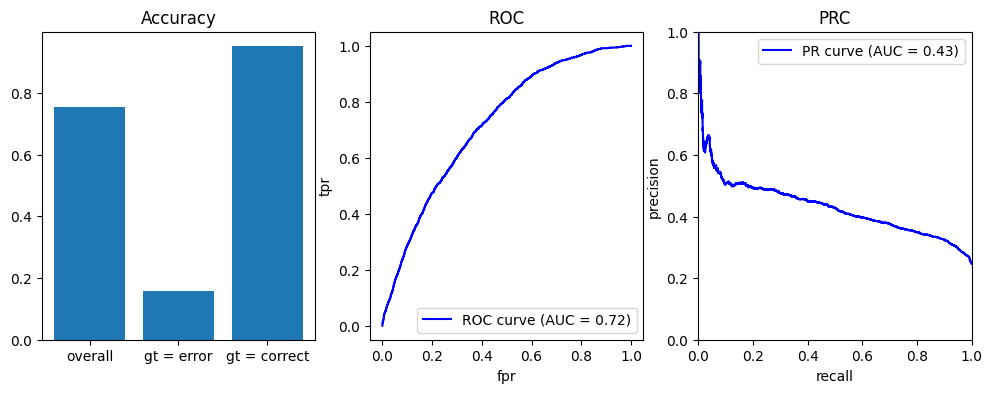

In [20]:
model_performance(final_model, test_features, test_labels)

Basically the same ROC as before, still worse than just knowing the decoded outputs. Note that precision struggles to top 60%. In other words, we can never get more that 60% of are reported positives being true positives.

- The situation is even worse when trying to detect multiple outputs vs single outputs.

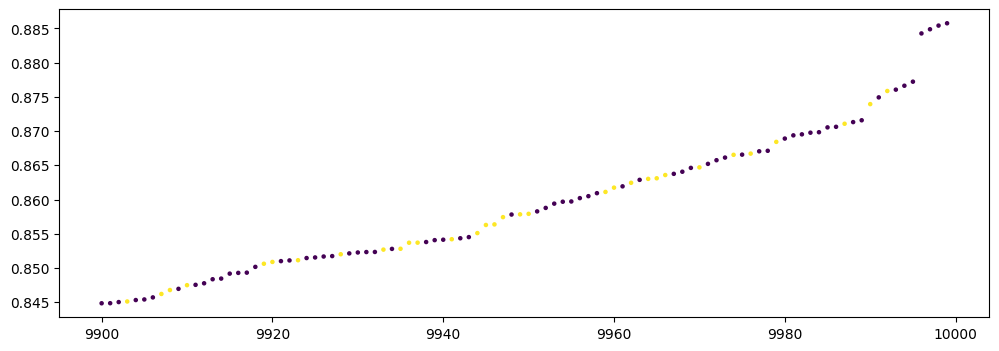

In [53]:
y_pred_proba = final_model.predict_proba(test_features)[:, 1]
sort_inds = np.argsort(y_pred_proba)
plt.scatter(np.arange(len(y_pred_proba))[-100:], y_pred_proba[sort_inds][-100:], c=test_labels[-100:], s=5, marker='o')

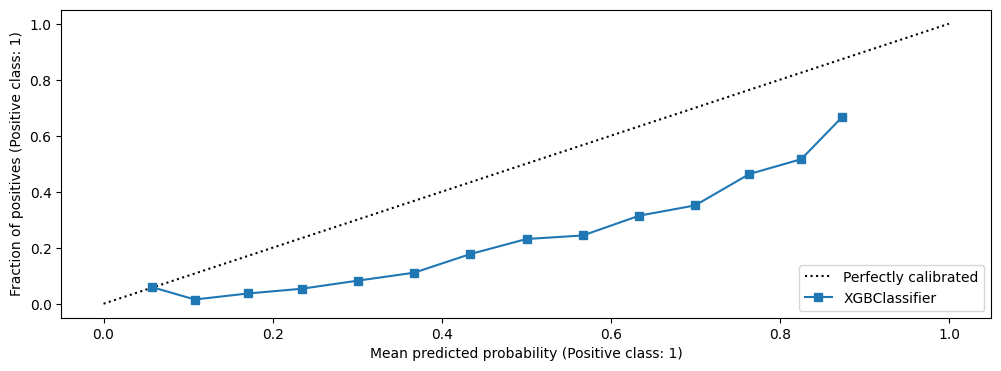

In [45]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

CalibrationDisplay.from_estimator(final_model,test_features, test_labels, n_bins=15)

Little predictive power.

Text(0.5, 1.0, 'Train curves')

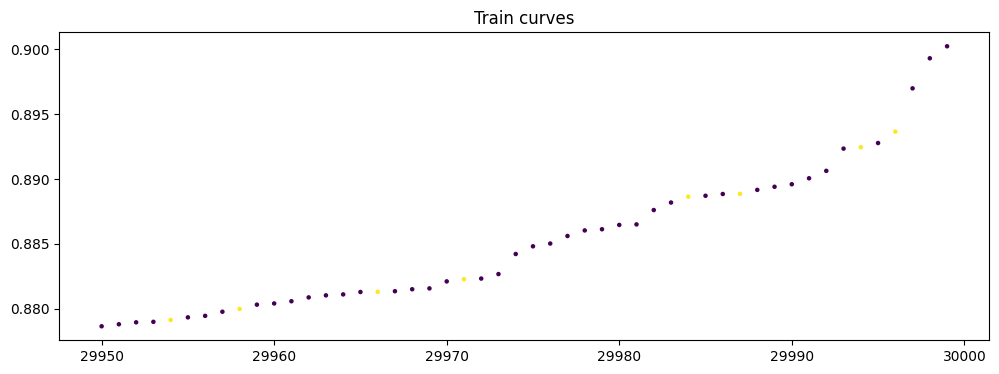

In [51]:
y_pred_proba = final_model.predict_proba(train_features)[:, 1]
sort_inds = np.argsort(y_pred_proba)
plt.scatter(np.arange(len(y_pred_proba))[-50:], y_pred_proba[sort_inds][-50:], c=train_labels[-50:], s=5, marker='o')
plt.title('Train curves')

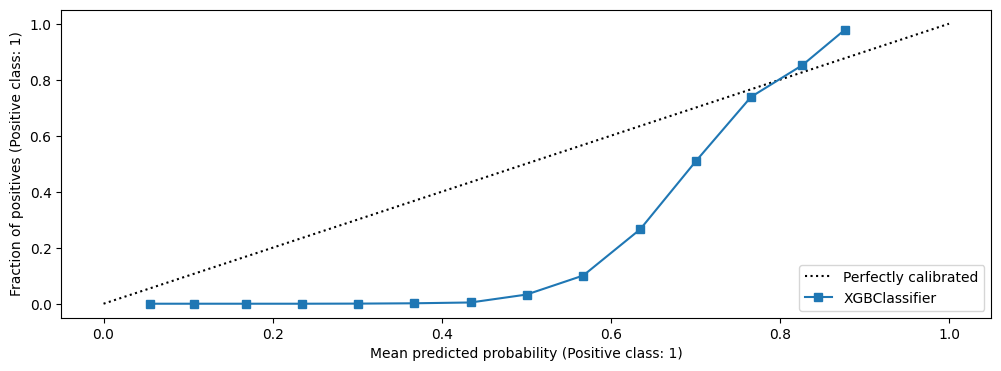

In [46]:
CalibrationDisplay.from_estimator(final_model,train_features, train_labels, n_bins=15)

Train curves don't look much better... I think that the feature extraction must be bad.

#### Notes on further investigations:

1. Training networks with sample weights + weight decay 0.1, I see an interesting 'switching' betwee 100% 0 answers and 100% 1 answers, but little in between.
2. Very difficult to find a spot where we get anything besides 'switching' or constant 0 or 1. Dropout seems required for switching.

- This applies to networks whether or not the data is mean-subtracted.

### Does randomization kill accuracy within classes?

In [4]:
from src.analysis.layer_randomization import model_accuracy
from src.analysis.layer_randomization import randomize_cls_token
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')

/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


In [5]:
# baseline
base_ckpt = '../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best'
readout_model = ClassifierWithTTA.from_pretrained(base_ckpt)
readout_model = readout_model.to('mps')
readout_model = readout_model.eval()

embedding_layers = 'embedding.vit.encoder.layer.{i}'
classifier_layers = 'classifier.vit.encoder.layer.{i}'

Loading weights from local directory


In [12]:
model_accuracy(readout_model, image_data).float().mean().item() 

100%|███████████████████████████████████████████| 79/79 [00:57<00:00,  1.38it/s]


0.7522000074386597

In [13]:
shuffled_within_acc = []

layer_name = classifier_layers.format(i=0)
for gt_class in range(200):
    subset = torch.utils.data.Subset(image_data, torch.where(image_data[:][1] == gt_class)[0])
    base_acc = model_accuracy(readout_model, subset).float().mean().item()  
    random_acc = randomize_cls_token(readout_model, layer_name, subset, randomization_mode='shuffle')
    norm_acc = randomize_cls_token(readout_model, layer_name, subset, randomization_mode='norm')
    
    shuffled_within_acc.append({'class': gt_class, 'baseline': base_acc, 'shuffled': random_acc,
                                'normal': norm_acc
                               })

shuffled_within_acc = pd.DataFrame(shuffled_within_acc)

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  2.95it/s]


<Axes: >

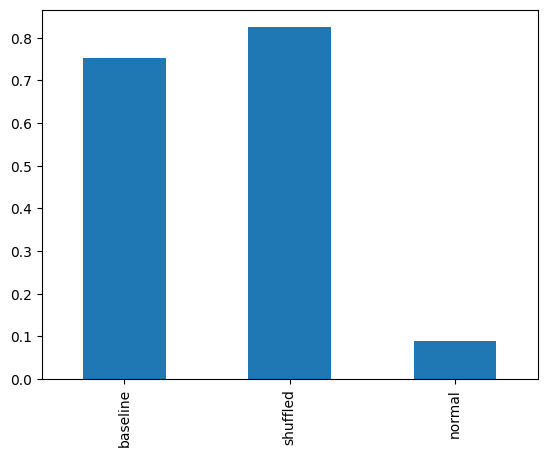

In [14]:
shuffled_within_acc.drop(columns='class').mean().plot.bar()

Shuffling _within_ a class appears to have almost no impact on accuracy. If anything, its a boost?

However, the accuracies coming out of this analysis seem somewhat noisy (over multiple runs)... Why would that be? The total accuracies are not as noise, we are simply averaging.

An accuracy boost is feasible for within-class shuffling, since we are _combining_ data from multiple samples of the same class.

This is another indicator that class data is _in_ the CLS tokens at this point, and they're not just 'setup' to handle the outputs well or something along those lines. In fact, the increase strengthens this point.

### Back to basics

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

In [21]:
val_ds = torch.load('../activity_analysis/2025-12-29_00_11_56_data_gen/activity_classifier_val.pt')
correct = val_ds['predictions'].mode().values == val_ds['gts']

counts = torch.tensor([ len(row.unique()) for row in val_ds['predictions']])


In [58]:
pca.fit(val_ds['activity'].view(-1, 768))

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [95]:
low_dim = pca.fit_transform(val_ds['activity'].view(-1, 768)).reshape(30000,50,2)

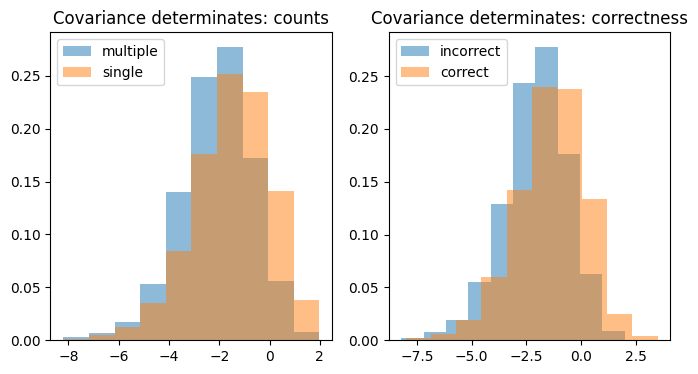

In [163]:
figsize(8,4)
covs = np.einsum('Nmk, Nmj -> Nkj', low_dim, low_dim) / 50
plt.subplots(1,2)
plt.subplot(1,2,1)
values, bins, _ =plt.hist( np.log(np.linalg.det(covs))[counts > 1],  density=True, alpha=0.5, label='multiple')
_=plt.hist( np.log(np.linalg.det(covs))[counts == 1], density=True, bins=bins, alpha=0.5, label='single')
_=plt.title('Covariance determinates: counts')
plt.legend()

plt.subplot(1,2,2)
_=plt.hist( np.log(np.linalg.det(covs))[~correct], density=True, bins=bins, alpha=0.5, label='incorrect')
values, bins, _ =plt.hist( np.log(np.linalg.det(covs))[correct],  density=True, alpha=0.5, label='correct')
_=plt.title('Covariance determinates: correctness')
plt.legend()

There is a slight tendency for multiple outputs and incorrect answers to show smaller covariance.

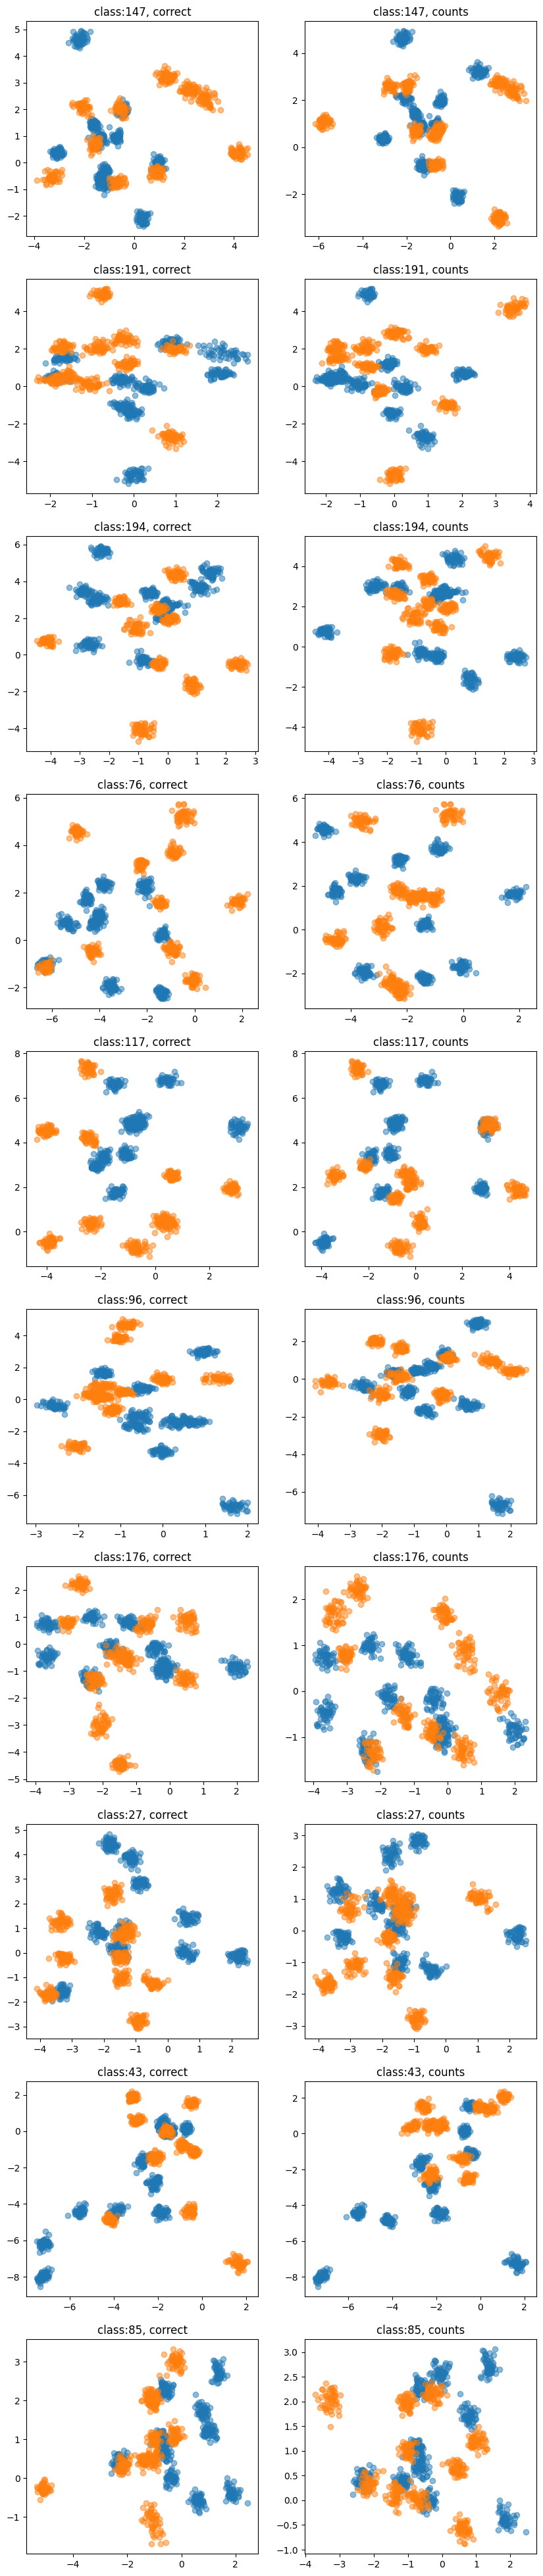

In [214]:
def plot_dists(datapoints, color):
    for row in datapoints:
        plt.scatter(row[:,0], row[:,1], c=color, alpha=0.5)

base_count=10
experiment_count=10
enforce_limits = False

figsize(10,50)
plt.subplots(10,2)

for i, gt in enumerate(torch.randperm(200)[0:10]):
    plt.subplot(10,2,2*i+1)
    plt.title(f'class:{gt}, correct')
    correct_dists = low_dim[(val_ds['gts']==gt) & correct][0:base_count]
    incorrect_dists = low_dim[(val_ds['gts']==gt) & ~correct][0:experiment_count]
    plot_dists(correct_dists, color='C0')
    plot_dists(incorrect_dists, color='C1')
    if enforce_limits:
        plt.xlim([-7,7])
        plt.ylim([-14,14])
    
    plt.subplot(10,2,2*i+2)
    plt.title(f'class:{gt}, counts')
    single_dists = low_dim[(val_ds['gts']==gt) & (counts==1)][0:base_count]
    multiple_dists = low_dim[(val_ds['gts']==gt) & (counts > 1)][0:experiment_count]
    plot_dists(single_dists, color='C0')
    plot_dists(multiple_dists, color='C1')
    if enforce_limits:
        plt.xlim([-7,7])
        plt.ylim([-14,14])

Text(0.5, 1.0, 'All classes mean activity, single vs multiple')

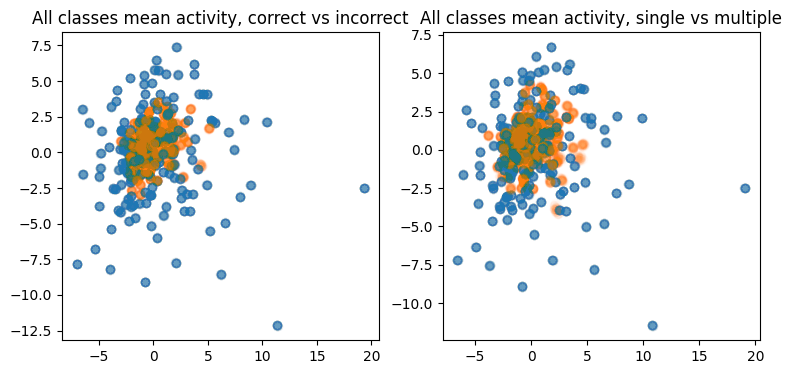

In [198]:
figsize(9,4)

plt.subplots(1,2)
plt.subplot(1,2,1)
def plot_mean(datapoints, color):
    mean = datapoints.mean(0)  
    plt.scatter(mean[:,0], mean[:,1], c=color, alpha=0.02)

for gt in range(200):
    correct_dists = low_dim[(val_ds['gts']==gt) & correct]
    incorrect_dists = low_dim[(val_ds['gts']==gt) & ~correct]
    plot_mean(correct_dists, color='C0')
    plot_mean(incorrect_dists, color='C1')

plt.title(f'All classes mean activity, correct vs incorrect')

plt.subplot(1,2,2)
figsize(4,4)
def plot_mean(datapoints, color):
    mean = datapoints.mean(0)  
    plt.scatter(mean[:,0], mean[:,1], c=color, alpha=0.02)

for gt in range(200):
    single_count = low_dim[(val_ds['gts']==gt) & (counts==1)]
    multi_count = low_dim[(val_ds['gts']==gt) & (counts > 1)]
    plot_mean(single_count, color='C0')
    plot_mean(multi_count, color='C1')
    
plt.title(f'All classes mean activity, single vs multiple')

In this plot: single, correct: blue.

In this low-dimensional space for _class conditional_ distrubitions, I often observe:
1. In many classes, the incorrect results tend to cluster spatially separately from the correct results.
    - Not all. Estimate ~50%
    - This is not detectable from multiple classes together
2.  Most classes seem to have similar 'spread' within individual images (note: requires enforcing axis limits). There is, of course, some variability, but not major.
3. I also don't see much in the way of patterns of spread between correct/incorrect or single/multiple count.


In the multiclass case, if wrong answers just look like answers from another class, then we have a problem: there is no way to tell those apart without knowing the actualy ground truth. This is a key difficulty that we will inevitably face.

#### Working backward: what do logits look like?


In [2]:
_, image_data_val = balanced_train_subsets(train_fraction=0.7, split='train')
del _

In [3]:
base_ckpt = '../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best'
readout_model = ClassifierWithTTA.from_pretrained(base_ckpt)
readout_model = readout_model.to('mps')
readout_model = readout_model.eval()

val_ds = torch.load('../activity_analysis/2025-12-29_00_11_56_data_gen/activity_classifier_val.pt')
correct = val_ds['predictions'].mode().values == val_ds['gts']

counts = torch.tensor([ len(row.unique()) for row in val_ds['predictions']])
torch.where(counts > 1)

Loading weights from local directory


(tensor([   21,    26,    27,  ..., 29984, 29990, 29997]),)

First, lets make sure that our outputs look similar:

In [4]:
i = 27
outputs_manual = torch.concat([readout_model(image_data_val[i:i+1][0].to('mps')).logits for rep in range(50)]).argmax(1)
outputs_extend = readout_model(image_data_val[i:i+1][0].to('mps').expand(50, 3, 224, 224)).logits.argmax(1)

print(outputs_manual)
print(outputs_extend)
print(val_ds['predictions'][i])

tensor([38, 38, 38, 38,  0, 38, 38, 38, 38, 38, 38, 38, 38,  0,  0,  0, 38, 38,
        38, 38, 38,  0, 38, 38,  0,  0, 38,  0,  0, 38,  0, 38,  0,  0, 38, 38,
         0, 38, 38, 38,  0, 38,  0, 38,  0, 38, 38, 38,  0,  0],
       device='mps:0')
tensor([ 38,   0,   0,   0,  38,  38,  38,   0,  38,   0,  38,   0,  38, 170,
         38,   0,  38,  38,  38,   0,  38,  38,  38,  38,   0,  38,  38,  38,
         38,  38,  38,  38,  38,  38, 170,  38,  38,  38,  38,   0,  38,  38,
         38,  38,  38,   0,  38,  38,   0,   0], device='mps:0')
tensor([ 38,   0,   0,  38,  38,  38,  38,  38,  38,   0,   0,  38,  38,  38,
         38,   0,  38,   0,  38,   0,  38,  38,  38,   0,   0,  38,  38,  38,
         38, 127,  38,  38,  38,  38,  38,  38,  38,  38,  38,  38,  38,  38,
         38,  38,   0,  38,  38,  38,  38,  38])


Looks good. I had an earlier bug that's fixed now.

In [29]:
i = 0 
logits_same = readout_model(image_data_val[i:i+1][0].to('mps').expand(50, 3, 224, 224)).logits.detach().cpu()
i= 27
logits_different = readout_model(image_data_val[i:i+1][0].to('mps').expand(50, 3, 224, 224)).logits.detach().cpu()
i= 5
logits_incorrect = readout_model(image_data_val[i:i+1][0].to('mps').expand(50, 3, 224, 224)).logits.detach().cpu()

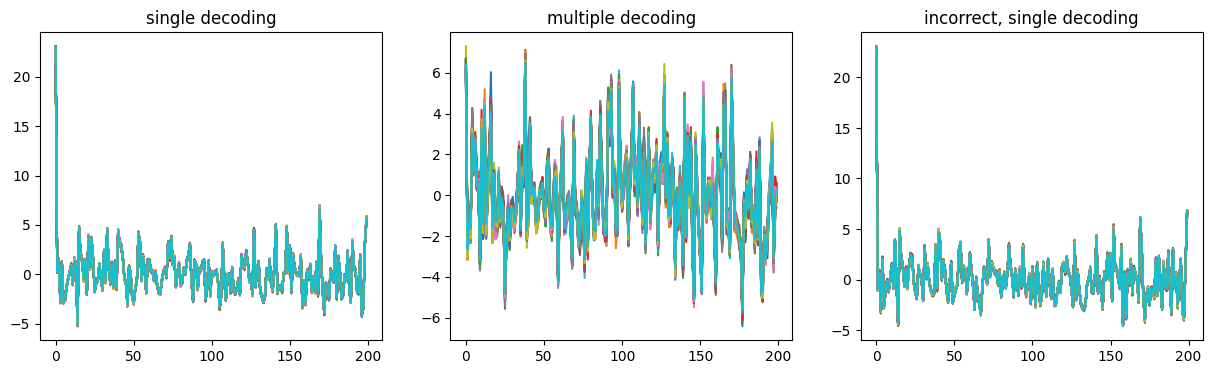

In [32]:
figsize(15, 4)
plt.subplots(1,3)
plt.subplot(1,3,1)
plt.title('single decoding')
for row in logits_same:
    plt.plot(row)

plt.subplot(1,3,2)
plt.title('multiple decoding')
for row in logits_different:
    plt.plot(row)

plt.subplot(1,3,3)
plt.title('incorrect, single decoding')
for row in logits_incorrect:
    plt.plot(row)

Multiple decodings occured (here) when the logits didn't favor any answer strongly.

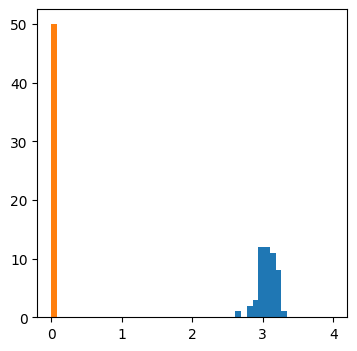

In [75]:
from torch.distributions import Categorical
figsize(4,4)
distribution = Categorical(logits=logits_different)
plt.hist(distribution.entropy(), bins=np.linspace(0,4))

distribution = Categorical(logits=logits_same)
_=plt.hist(distribution.entropy(), bins=np.linspace(0,4))


Suggests that multiple decoding can be reduced to certainty of a single trajectory.

In [92]:
# compute entropies for all datapoints
dl = torch.utils.data.DataLoader(image_data_val, shuffle=False, batch_size=128)

entropies = []
all_logits = []

for batch in tqdm(iter(dl), total=len(image_data_val)//128 ):
    images, labels = batch
    logits = readout_model(images.to('mps')).logits.detach().cpu()
    all_logits.append(logits)
    
    distribution = Categorical(logits=logits)
    entropies.append(distribution.entropy())

entropies = torch.concat(entropies)
all_logits = torch.concat(all_logits)

235it [03:03,  1.28it/s]                                                        


In [93]:
entropy_vs_count = pd.DataFrame({'count':counts, 'entropy': entropies})

<Axes: xlabel='count', ylabel='entropy'>

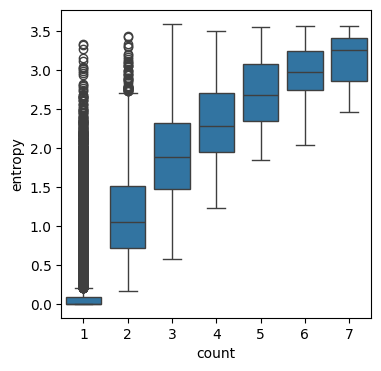

In [94]:
sns.boxplot(entropy_vs_count, x='count', y='entropy')

Yes. Entropy and counts line up very well. I'll look into some of the points where this differs, but it worth noting that random sampling could lead to degree of cross-over.

In [95]:
entropy_vs_count[(entropy_vs_count['count']==1)]['entropy'].median()

np.float32(0.0013995359)

In [96]:
entropy_vs_count[(entropy_vs_count['count']>1)]['entropy'].min()

np.float32(0.16749959)

In [139]:
entropy_vs_count[(entropy_vs_count['count']==1) & (entropy_vs_count['entropy'] > 0.5)]

,count,entropy
4,1,0.510925
7,1,1.001479
52,1,0.561920
53,1,0.796128
83,1,0.788154
...,...,...
29919,1,1.228280
29930,1,0.629252
29959,1,0.577126
29962,1,0.943173


/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


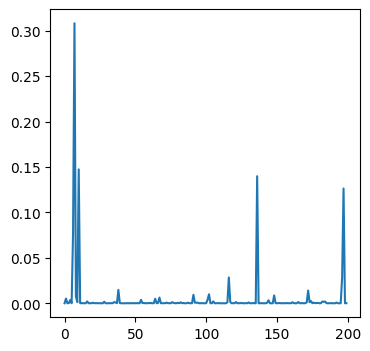

In [127]:
sm = torch.nn.Softmax()
plt.plot(sm(all_logits[202]))

In [128]:
val_ds['predictions'][202]

tensor([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7])

In [129]:
all_logits[202].argmax()

tensor(7)

/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


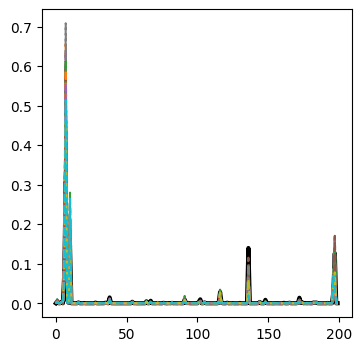

In [135]:
i = 202
plt.plot(sm(all_logits[i]), '-k', linewidth=3)
logits_interesting = readout_model(image_data_val[i:i+1][0].to('mps').expand(50, 3, 224, 224)).logits.detach().cpu()
for row in logits_interesting:
    plt.plot(sm(row), '--')



(array([ 1.,  1.,  3., 15., 11.,  5.,  4.,  7.,  2.,  1.]),
 array([0.24579808, 0.29207507, 0.33835205, 0.38462907, 0.43090606,
        0.47718304, 0.52346003, 0.56973702, 0.616014  , 0.66229099,
        0.70856798]),
 <BarContainer object of 10 artists>)

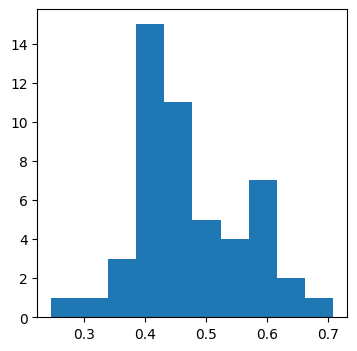

In [137]:
plt.hist(sm(logits_interesting)[:,7])

It's hard to visualize, but what appears to be happening in this interesting case is that the curves are not tightly peaked, but the noise is never sufficient to push the (here) correct logit below any of the competition.

#### Conclusion here:

Multiple decodings reduces almost entirely to the _certainty_ in the representation. Essentially, CLS token noise acts as a random perturbation that rides along the into the logits. It will cause multiple decodings in uncertain distributions.

This indicates that certainty measures are _as good of a signal as multiple decodings_. Need to read up, but other people have found that TTA models are _over-confident_. That puts the whole idea behind this investigation in jeopardy.